#ZOMATO BANGALORE DATA ANALYSIS

## Objective:
### To perform Exploratory Data Analysis (EDA) on the Zomato Bangalore dataset and generate meaningful business insights using Python.

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/zomato_rest_data.xlsx - Sheet1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

#Task 1: Data Understanding & Cleaning  

##1.  Dataset Exploration

In [ ]:
# Getting first 5 rows data
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
# dimensions of dataset
df.shape

(51717, 18)

In [ ]:
# total column names and their datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

In [ ]:
# total null values in each column
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


#Data Cleaning

In [ ]:
# Unnamed: 0 Column
df.drop(columns = ['Unnamed: 0'], inplace = True) # Dropping column

In [ ]:
# url column
df.drop(columns = ['url'], inplace = True) #Dropping column

In [ ]:
# address column
df.drop(columns = ['address'], inplace = True) #Dropping column

In [ ]:
# name column
df["name"]=df['name'].str.capitalize()

In [ ]:
# rate column
df['rate']=df['rate'].str.strip('/5') # Removing unwanted data "/5"
df['rate'] = df['rate'].replace(['NEW','-','0'],np.nan) # Changing specific data in a column "NEW" and '-'
df['rate']=df['rate'].astype(float) # Changing the datatype to float
mean = df["rate"].mean().round(1)
df['rate']=df['rate'].fillna(mean) #Handling missing values
df["rate"].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 2.6, 3.4, 2. , 2.7, 4.7, 2.4, 2.2, 2.3, 4.8, 3.5,
       2.5, 4.5, 4.9, 2.1, 1.8])

In [ ]:
# phone column
df.drop(columns = ['phone'], inplace = True) #Dropping column

In [ ]:
# location column
df.drop(columns = ['location'], inplace = True) #Dropping column

In [ ]:
# rest_type column
df.drop(columns = ['rest_type'], inplace = True) #Dropping column

In [ ]:
# dish_liked column
df["dish_liked"]=df["dish_liked"].fillna(df["dish_liked"].mode()[0]) # Handling null values
df["dish_liked"].unique()

array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [ ]:
# cuisines column
df["cuisines"]=df["cuisines"].fillna(df["cuisines"].mode()[0]) # Handling null values
df["cuisines"].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

In [ ]:
# approx_cost(for two people) column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '') # removing ',' in the data
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float) # changing datatype to float
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].mean().round()) # Handling null values
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int) # Changing datatype to int
df.rename(columns = {'approx_cost(for two people)':'cost_per_2'}, inplace = True) # renaming the "approx_cost(for two people)" to "cost_per_2"
df["cost_per_2"].unique()

array([ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,
        750,  150,  850,  100, 1200,  350,  250,  950, 1000, 1500, 1300,
        199,   80, 1100,  160, 1600,  230,  130,   50,  190, 1700,  555,
       1400,  180, 1350, 2200, 2000, 1800, 1900,  330, 2500, 2100, 3000,
       2800, 3400,   40, 1250, 3500, 4000, 2400, 2600,  120, 1450,  469,
         70, 3200,   60,  560,  240,  360, 6000, 1050, 2300, 4100, 5000,
       3700, 1650, 2700, 4500,  140])

In [ ]:
# reviews_list column
df.drop(columns = ['reviews_list'], inplace = True) #Dropping column

In [ ]:
# menu_item column
df.drop(columns = ['menu_item'], inplace = True) #Dropping column

In [ ]:
# listed_in(type) column
df.rename(columns = {'listed_in(type)':'dining_mode'}, inplace = True) # Renaming column "listed_in(type)" to "dining_mode"
df["dining_mode"]=df['dining_mode'].str.capitalize()
df["dining_mode"].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [ ]:
# listed_in(city) column
df.rename(columns = {'listed_in(city)':'location'}, inplace = True) # Renaming column "listed_in(city)" to "location"
df["location"]=df['location'].str.capitalize()
df['location'].unique()

array(['Banashankari', 'Bannerghatta road', 'Basavanagudi', 'Bellandur',
       'Brigade road', 'Brookefield', 'Btm', 'Church street',
       'Electronic city', 'Frazer town', 'Hsr', 'Indiranagar',
       'Jayanagar', 'Jp nagar', 'Kalyan nagar', 'Kammanahalli',
       'Koramangala 4th block', 'Koramangala 5th block',
       'Koramangala 6th block', 'Koramangala 7th block', 'Lavelle road',
       'Malleshwaram', 'Marathahalli', 'Mg road', 'New bel road',
       'Old airport road', 'Rajajinagar', 'Residency road',
       'Sarjapur road', 'Whitefield'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51717 non-null  object 
 1   online_order  51717 non-null  object 
 2   book_table    51717 non-null  object 
 3   rate          51717 non-null  float64
 4   votes         51717 non-null  int64  
 5   dish_liked    51717 non-null  object 
 6   cuisines      51717 non-null  object 
 7   cost_per_2    51717 non-null  int64  
 8   dining_mode   51717 non-null  object 
 9   location      51717 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 3.9+ MB


#Univariate Analysis

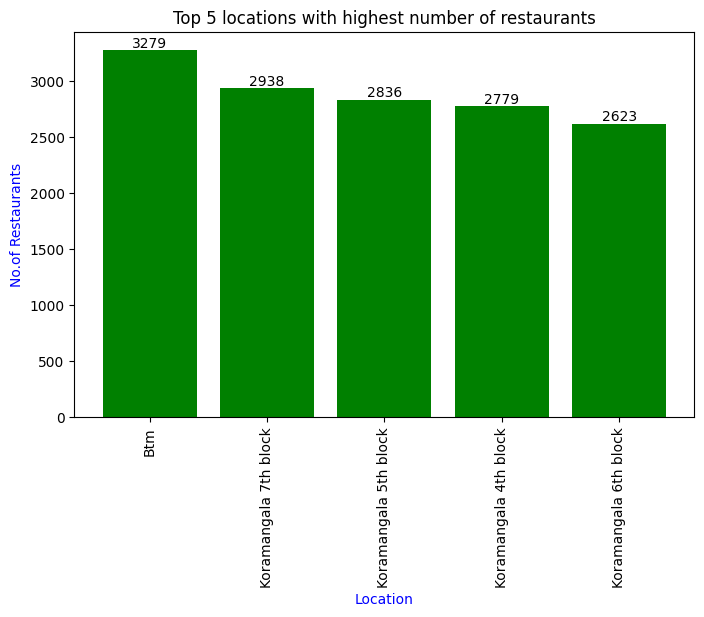

In [ ]:
# 1) Top 5 locations with highest number of restaurants
top_locations = df['location'].value_counts().head(5) # getting top 5 locations with highest restaurants
df1=pd.DataFrame(top_locations)
df1.reset_index(inplace = True)

#plotting a bar plot for better visualization of top 5 locations which have highest no.of restaurants
# creation
plt.figure(figsize=(8,5))
loc = plt.bar(x=df1['location'], height=df1['count'],color="green")
# customization
plt.xlabel('Location',color="blue")
plt.ylabel('No.of Restaurants',color="blue")
plt.title('Top 5 locations with highest number of restaurants')
plt.xticks(rotation=90)
plt.bar_label(loc)
plt.show()

Top 5 locations with highest no.of restaurants are:
1. Btm
2. Koramangala 7th block
3. Koramangala 5th block
4. Koramangala 4th block
5. Koramangala 6th block

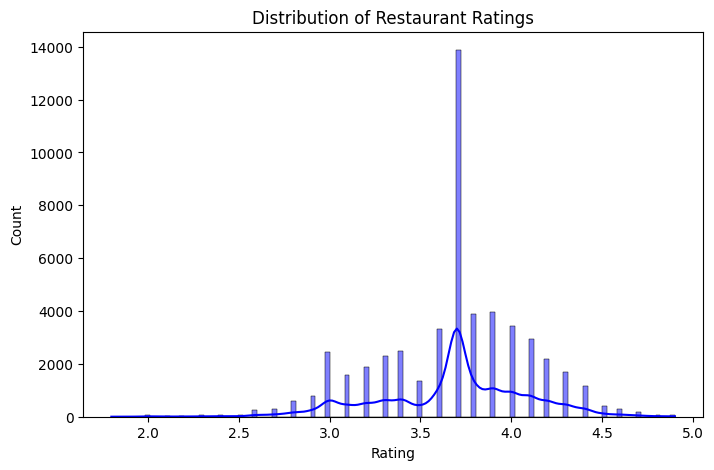

In [ ]:
# 2) Distribution of restaurant ratings
plt.figure(figsize=(8,5))
#plotting a hist plot for visual understanding of distribution of restaurant ratings
# creation
sns.histplot(df['rate'],kde=True,color="blue")
# customization
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


As per the distribution
- For most of the restaurants the rating is falls between 3.5 to 4.0
- Mostly given rating by the customers is approximately 3.7

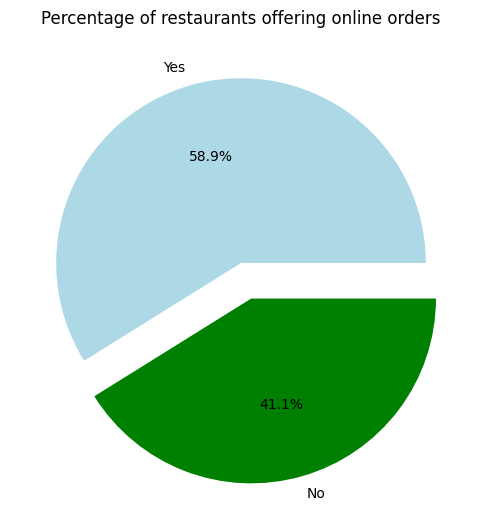

In [ ]:
# 3) Percentage of restaurants offering online orders
online_orders = df['online_order'].value_counts()
df1=pd.DataFrame(online_orders)
df1.reset_index(inplace = True)
#plotting a pie chart for visual understanding and for getting percentages
# creation
plt.figure(figsize=(6,6))
plt.pie(df1['count'], labels=df1['online_order'], autopct='%1.1f%%',colors=["lightblue","green"], explode=(0,0.2))
plt.title("Percentage of restaurants offering online orders")
plt.show()

58.9 percent of restaurants are offering online orders

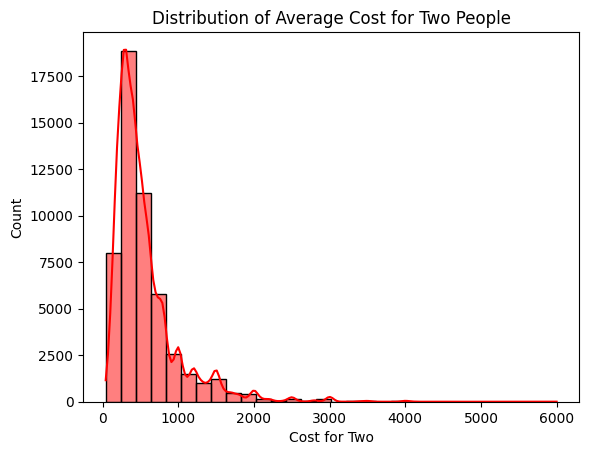

In [ ]:
# 4) Distribution of average cost for two
#plotting a hist plot for visual understanding distribution of average cost for two people
# creation
sns.histplot(df['cost_per_2'], kde=True, color="red")
# customization
plt.title("Distribution of Average Cost for Two People")
plt.xlabel("Cost for Two")
plt.ylabel("Count")
plt.show()

Most restaurants fall in the ₹200–₹1000 range and this shows there are more affordable restaurants

#Task 3: Bivariate Analysis

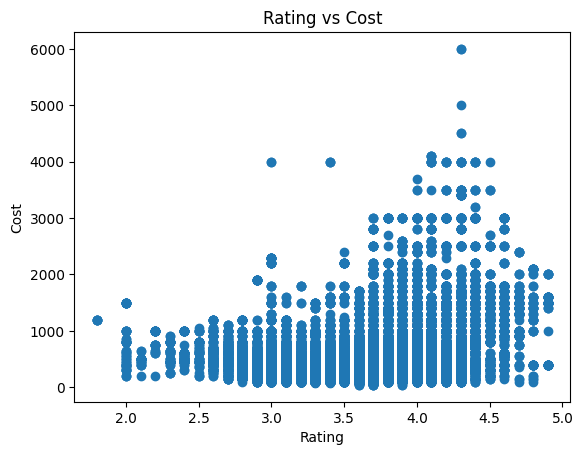

In [ ]:
# 1. Rating vs Cost
#plotting a scatter plot for visual understanding (Rating vs Cost)
plt.scatter(df["rate"],df["cost_per_2"])
plt.title("Rating vs Cost")
plt.xlabel("Rating")
plt.ylabel("Cost")
plt.show()

Ratings are better for low cost restaurants compared to costly restaurants

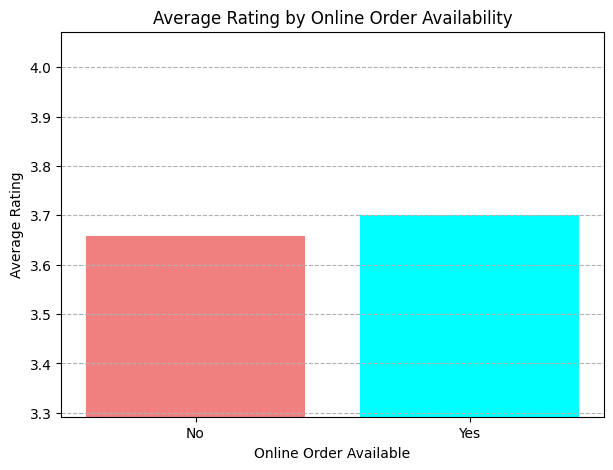

In [ ]:
# Rating vs Online Order
# Calculating the average rating for each online_order category
average_ratings = df.groupby('online_order')['rate'].mean().reset_index()
# plotting bar plot
plt.figure(figsize=(7, 5))
plt.bar(average_ratings['online_order'], average_ratings['rate'], color=['lightcoral','cyan'])
plt.title('Average Rating by Online Order Availability')
plt.xlabel('Online Order Available')
plt.ylabel('Average Rating')
# Set y-axis limits for better visualization
plt.ylim(average_ratings['rate'].min() * 0.9, average_ratings['rate'].max() * 1.1)
plt.grid(axis='y', linestyle='--')
plt.show()

- The average rating is a bit more for resturants which provide online order service and less for resturants which are not having online order service.
- But it is a neglegable difference between the average ratings depending on online order availability so it is optional to consider this as a factor that effects rating

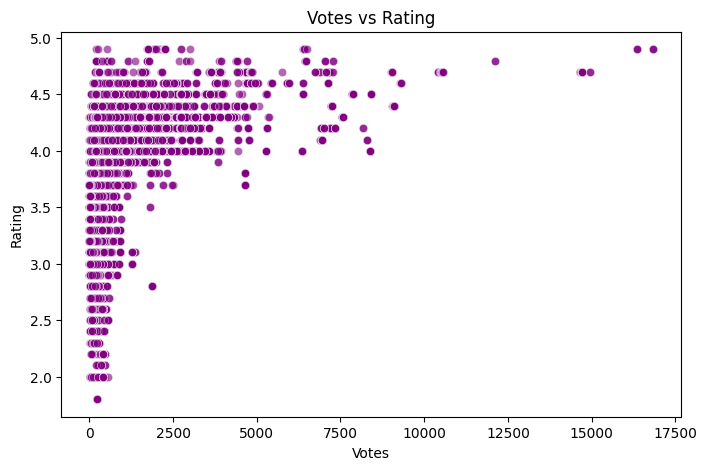

In [ ]:
# 3. Votes vs Rating
plt.figure(figsize=(8,5))
#plotting a scatter plot for visual understanding (Votes vs Rating)
sns.scatterplot(x='votes',y='rate',data=df,,color="purple")
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

- Restaurants with more votes have stable ratings between 3.5–4.5.
- High vote count do not guarantee higher ratings.

#Task 4: Business Insights & Recommendations


1. Does higher cost lead to higher ratings?  
- No, Ratings are better for low cost restaurants compared to expensive restaurants

2. Does offering online order impact ratings?  
- The average rating is a bit more for resturants which provide online order service and less for resturants which are not having online order service.
- But it is a neglegable difference between the average ratings depending on online order availability so it is optional to consider this as a factor that effects rating

3. Which location appears highly competitive?  
- BTM is highly competitive due to dense restaurant presence.

4. Where would you recommend opening a new restaurant?  
- New BEL road or Banashankari would be better locations to open a new restaurants

In [ ]:
df.to_csv("ZOMATO_BANGALORE_DATA_ANALYSIS.csv")